# FIFA Players Performance and Market Value Analysis

## Data Visualization Final Project

**Dataset:** FIFA Players Dataset

**Objective:**
This project aims to analyze the FIFA Players dataset to understand the factors influencing player performance, market value, wages, and potential through interactive Plotly visualizations and a Streamlit dashboard.

In [104]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [105]:
df = pd.read_csv(r"C:\Users\gurud\Downloads\FIFA_Data_Visualization_Project\data\fifa_players.csv")

# Loading the Dataset

In [106]:
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [107]:
df.shape

(17954, 51)

In [108]:
(17954, 51)

(17954, 51)

# Data Cleaning

In [109]:
df.columns

Index(['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs',
       'positions', 'nationality', 'overall_rating', 'potential', 'value_euro',
       'wage_euro', 'preferred_foot', 'international_reputation(1-5)',
       'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type',
       'release_clause_euro', 'national_team', 'national_rating',
       'national_team_position', 'national_jersey_number', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'],
      dtype='object')

In [110]:
df.isnull().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

# Exploratory Data Analysis (EDA)

In [113]:
df.describe()

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,1.769900e+04,17708.000000,17954.000000,17954.000000,17954.000000,...,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000,17954.000000
mean,25.565445,174.946921,75.301047,66.240169,71.430935,2.479280e+06,9902.134628,1.111674,2.945695,2.361034,...,46.852456,55.816531,46.657959,49.857302,53.406260,48.357302,58.680183,47.162861,47.733040,45.705915
std,4.705708,14.029449,7.083684,6.963730,6.131339,5.687014e+06,21995.593750,0.392168,0.663691,0.763223,...,19.429337,17.394047,20.754649,19.694311,14.156038,15.810844,11.625541,20.037346,21.674973,21.285812
min,17.000000,152.400000,49.900000,47.000000,48.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,3.000000,11.000000,3.000000,2.000000,10.000000,5.000000,12.000000,3.000000,2.000000,3.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,2.000000,...,32.000000,44.000000,26.000000,38.000000,44.000000,38.000000,51.000000,30.000000,27.000000,24.000000
50%,25.000000,175.260000,74.800000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,2.000000,...,51.000000,59.000000,52.000000,55.000000,55.000000,49.000000,60.000000,52.500000,55.000000,52.000000
75%,29.000000,185.420000,79.800000,71.000000,75.000000,2.100000e+06,9000.000000,1.000000,3.000000,3.000000,...,62.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.000000,64.000000,66.000000,64.000000
max,46.000000,205.740000,110.200000,94.000000,95.000000,1.105000e+08,565000.000000,5.000000,5.000000,5.000000,...,94.000000,95.000000,92.000000,95.000000,94.000000,92.000000,96.000000,94.000000,93.000000,90.000000


## Missing Values Analysis

In [114]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

value_euro                  255
wage_euro                   246
release_clause_euro        1837
national_team             17097
national_rating           17097
national_team_position    17097
national_jersey_number    17097
dtype: int64

### Observation

The above output shows only the columns containing missing values. These columns will be analysed to determine whether missing values should be removed or filled.

## Duplicate Records

In [115]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0



### Observation

No duplicate records were found in the dataset. Therefore, no rows were removed during the data cleaning process.


In [116]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

national_team             95.226690
national_rating           95.226690
national_team_position    95.226690
national_jersey_number    95.226690
release_clause_euro       10.231703
value_euro                 1.420296
wage_euro                  1.370168
dtype: float64

## Data Types

In [117]:
df.dtypes

name                              object
full_name                         object
birth_date                        object
age                                int64
height_cm                        float64
weight_kgs                       float64
positions                         object
nationality                       object
overall_rating                     int64
potential                          int64
value_euro                       float64
wage_euro                        float64
preferred_foot                    object
international_reputation(1-5)      int64
weak_foot(1-5)                     int64
skill_moves(1-5)                   int64
body_type                         object
release_clause_euro              float64
national_team                     object
national_rating                  float64
national_team_position            object
national_jersey_number           float64
crossing                           int64
finishing                          int64
heading_accuracy

### Observation

No duplicate records were found in the dataset. Therefore, no rows were removed during the data cleaning process.

In [118]:
# Fill missing values using the median

df["value_euro"] = df["value_euro"].fillna(df["value_euro"].median())

df["wage_euro"] = df["wage_euro"].fillna(df["wage_euro"].median())

df["release_clause_euro"] = df["release_clause_euro"].fillna(df["release_clause_euro"].median())

In [119]:
df.isnull().sum()

name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                           0
wage_euro                            0
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro                  0
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing            

### Observation

Missing values in `value_euro`, `wage_euro`, and `release_clause_euro` were replaced with the median because only a small percentage of values were missing.

The national team-related columns were intentionally left unchanged because the missing values indicate that many players do not represent their national teams. These missing values are meaningful rather than errors.

# Exploratory Data Analysis (EDA)

## Dataset Overview

In [120]:
print("Number of Players:", len(df))

print("Number of Columns:", len(df.columns))

print("Number of Nationalities:", df["nationality"].nunique())

print("Number of Playing Positions:", df["positions"].nunique())

Number of Players: 17954
Number of Columns: 51
Number of Nationalities: 160
Number of Playing Positions: 890


## Player Age Statistics

In [121]:
print("Average Age:", round(df["age"].mean(),2))

print("Youngest Player:", df["age"].min())

print("Oldest Player:", df["age"].max())

Average Age: 25.57
Youngest Player: 17
Oldest Player: 46


## Overall Rating Statistics

In [122]:
print("Average Overall Rating:", round(df["overall_rating"].mean(),2))

print("Highest Overall Rating:", df["overall_rating"].max())

print("Lowest Overall Rating:", df["overall_rating"].min())

Average Overall Rating: 66.24
Highest Overall Rating: 94
Lowest Overall Rating: 47


## Market Value Statistics

In [123]:
print("Highest Player Value (€):", df["value_euro"].max())

print("Average Player Value (€):", round(df["value_euro"].mean(),2))

Highest Player Value (€): 110500000.0
Average Player Value (€): 2454009.13


## Wage Statistics

In [124]:
print("Highest Wage (€):", df["wage_euro"].max())

print("Average Wage (€):", round(df["wage_euro"].mean(),2))

Highest Wage (€): 565000.0
Average Wage (€): 9807.56


## Top 10 Nationalities

In [125]:
df["nationality"].value_counts().head(10)

nationality
England        1658
Germany        1199
Spain          1070
France          925
Argentina       904
Brazil          832
Italy           655
Colombia        624
Japan           466
Netherlands     441
Name: count, dtype: int64

## Most Common Playing Positions

In [126]:
df["positions"].value_counts().head(10)

positions
CB        2243
GK        2065
ST        1747
CM         764
CDM,CM     709
LB         672
CM,CDM     632
RB         605
CDM        321
CB,RB      268
Name: count, dtype: int64

# Analytical Questions

## Question 1

How does a player's overall rating influence their market value?

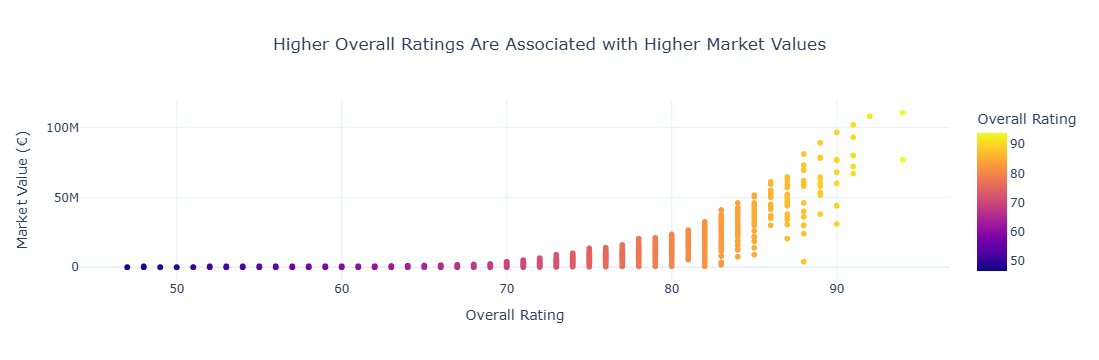

In [127]:
fig = px.scatter(
    df,
    x="overall_rating",
    y="value_euro",
    hover_name="full_name",
    color="overall_rating",
    title="Higher Overall Ratings Are Associated with Higher Market Values",
    labels={
        "overall_rating": "Overall Rating",
        "value_euro": "Market Value (€)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The scatter plot indicates a positive relationship between a player's overall rating and market value. Players with higher overall ratings generally command significantly higher transfer values, although there is some variation caused by factors such as age, position, and potential.

## Question 2

Does player age affect market value?

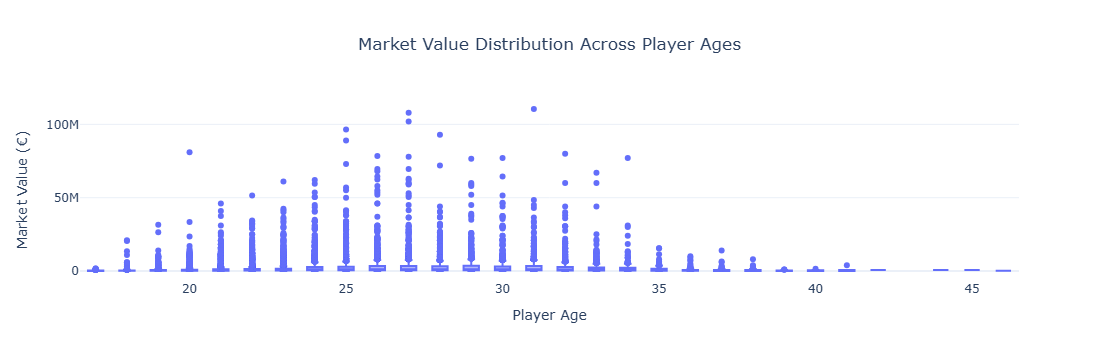

In [128]:
fig = px.box(
    df,
    x="age",
    y="value_euro",
    title="Market Value Distribution Across Player Ages",
    labels={
        "age": "Player Age",
        "value_euro": "Market Value (€)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False
)

fig.show()

### Insight

The box plot shows how market values vary across different ages. It helps identify the age groups where players tend to achieve the highest market values, while also revealing the spread and presence of exceptionally valuable players (outliers). This suggests that market value is influenced by age, but not all players of the same age have similar values.

## Question 3

Which playing positions receive the highest wages?

In [129]:
# Calculate average wage by position
position_wages = (
    df.groupby("positions")["wage_euro"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    position_wages,
    x="positions",
    y="wage_euro",
    color="wage_euro",
    title="Top 10 Playing Positions by Average Wage",
    labels={
        "positions": "Playing Position",
        "wage_euro": "Average Wage (€)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_tickangle=-45
)

fig.show()

### Insight

The bar chart compares the average wages across different playing positions. It highlights which positions receive the highest salaries and suggests that wage levels vary considerably depending on the role a player performs on the field. Positions associated with higher wages may reflect greater demand, influence on team performance, or scarcity of elite players.

## Question 4

Which nationalities produce the highest-rated players?

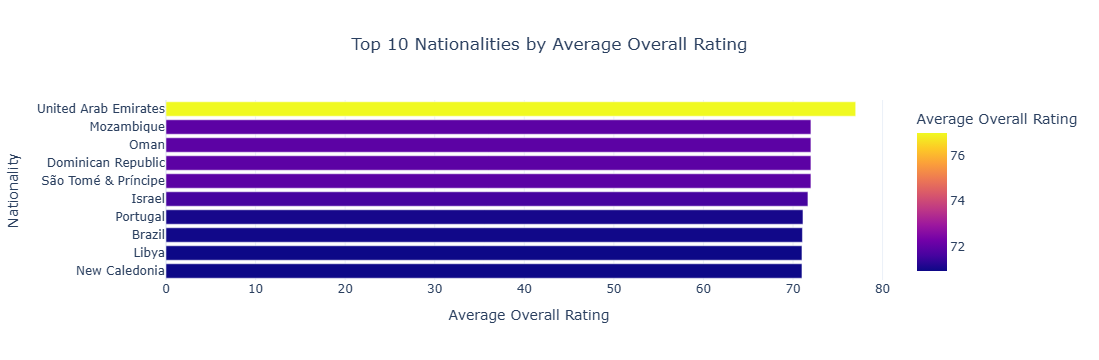

In [130]:
# Calculate average overall rating for each nationality
top_nationalities = (
    df.groupby("nationality")["overall_rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_nationalities,
    x="overall_rating",
    y="nationality",
    orientation="h",
    color="overall_rating",
    title="Top 10 Nationalities by Average Overall Rating",
    labels={
        "overall_rating": "Average Overall Rating",
        "nationality": "Nationality"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Insight

The chart compares the average overall ratings of players from different nationalities. It shows which countries consistently produce highly rated footballers. Differences in average ratings may reflect the strength of football development systems, player development programs, and the number of elite players representing each nation.

## Question 5

Does player potential influence market value?

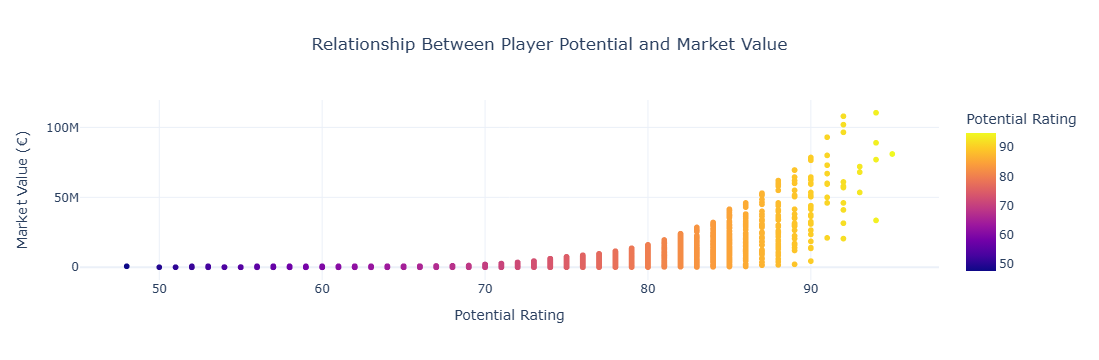

In [131]:
fig = px.scatter(
    df,
    x="potential",
    y="value_euro",
    color="potential",
    hover_name="full_name",
    title="Relationship Between Player Potential and Market Value",
    labels={
        "potential": "Potential Rating",
        "value_euro": "Market Value (€)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The scatter plot shows a positive relationship between a player's potential and market value. Players with higher potential ratings generally have higher market values because clubs are willing to invest more in players who are expected to improve in the future. However, there are exceptions where some players have high potential but relatively lower market values due to factors such as age, current performance, or playing position.

## Question 6

What is the relationship between overall rating and wages?

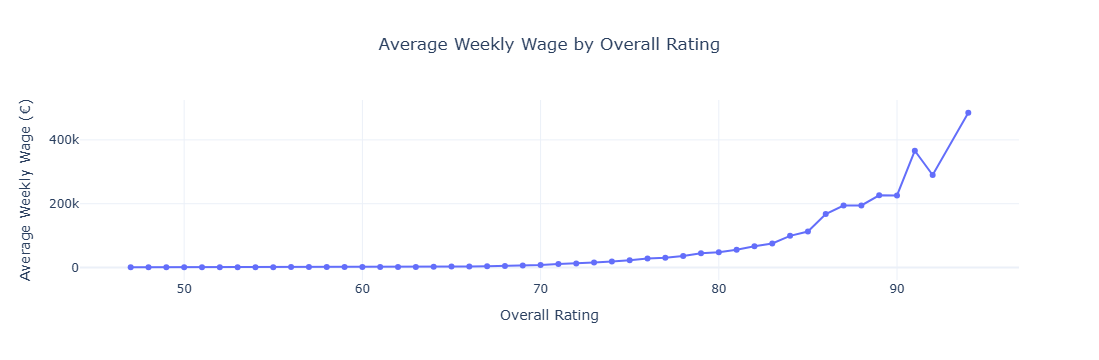

In [132]:
# Calculate average wage for each overall rating
rating_wage = (
    df.groupby("overall_rating")["wage_euro"]
      .mean()
      .reset_index()
)

fig = px.line(
    rating_wage,
    x="overall_rating",
    y="wage_euro",
    markers=True,
    title="Average Weekly Wage by Overall Rating",
    labels={
        "overall_rating": "Overall Rating",
        "wage_euro": "Average Weekly Wage (€)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The Line chart shows a strong positive relationship between a player's overall rating and weekly wage. Players with higher overall ratings generally receive higher wages. The bubble size represents the player's market value, indicating that many highly rated players are also among the most valuable in the transfer market. However, some players with similar ratings earn different wages due to factors such as club finances, contracts, experience, and reputation.

## Question 7

Which technical attributes are strongest among elite players?

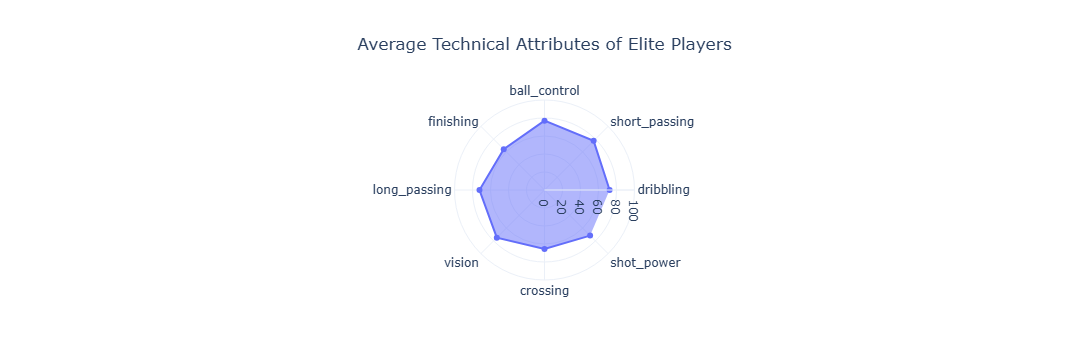

In [138]:
# Select elite players (Overall Rating >= 85)
elite_players = df[df["overall_rating"] >= 85]

# Calculate average technical attributes
attributes = [
    "dribbling",
    "short_passing",
    "ball_control",
    "finishing",
    "long_passing",
    "vision",
    "crossing",
    "shot_power"
]

avg_attributes = elite_players[attributes].mean()

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=avg_attributes.values,
    theta=attributes,
    fill='toself',
    name='Elite Players'
))

fig.update_layout(
    title="Average Technical Attributes of Elite Players",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The radar chart illustrates the average technical attributes of elite players with an overall rating of 85 or above. It shows that skills such as ball control, dribbling, short passing, and vision are consistently strong among top-performing players. This suggests that technical ability is a key characteristic of elite footballers.

## Question 8

How do left-footed and right-footed players differ in performance?

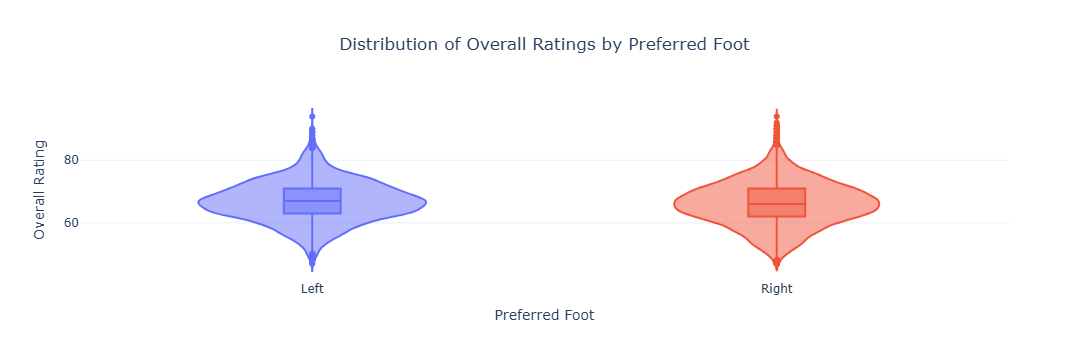

In [134]:
fig = px.violin(
    df,
    x="preferred_foot",
    y="overall_rating",
    color="preferred_foot",
    box=True,
    points="outliers",
    title="Distribution of Overall Ratings by Preferred Foot",
    labels={
        "preferred_foot": "Preferred Foot",
        "overall_rating": "Overall Rating"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False
)

fig.show()

### Insight

The violin plot compares the distribution of overall ratings between left-footed and right-footed players. It shows the spread, median, and density of player ratings for each group. The analysis indicates whether one group tends to have higher ratings or if both groups perform similarly overall.

## Question 9

Which players offer the greatest future potential?

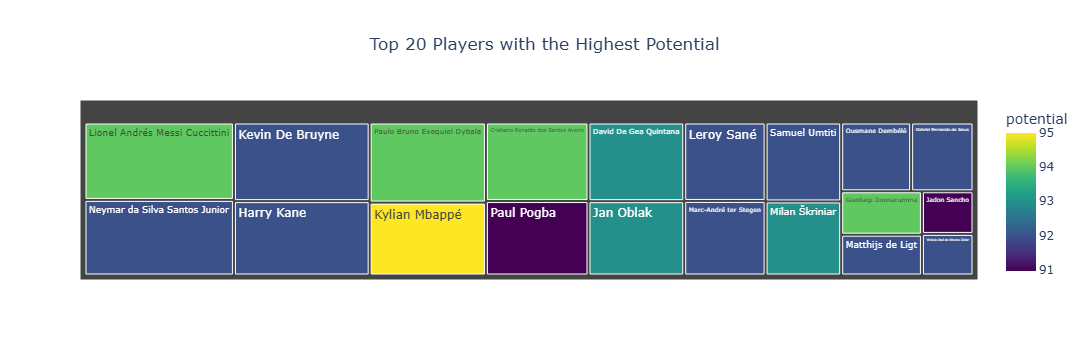

In [135]:
# Select the top 20 players based on potential
top_potential = (
    df.sort_values(by="potential", ascending=False)
      .head(20)
)

fig = px.treemap(
    top_potential,
    path=["full_name"],
    values="value_euro",
    color="potential",
    color_continuous_scale="Viridis",
    title="Top 20 Players with the Highest Potential"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The treemap highlights the top 20 players with the highest potential ratings. The size of each rectangle represents the player's market value, while the colour indicates their potential rating. Players with both high potential and high market value are considered valuable long-term investments for football clubs, as they are expected to improve and contribute significantly in the future.

## Question 10

Which player attributes are most strongly associated with overall rating?

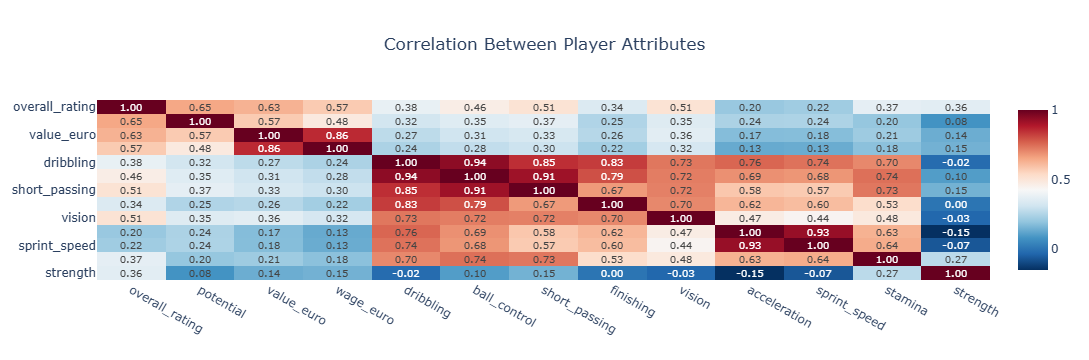

In [137]:
# Select relevant numerical attributes
correlation_data = df[[
    "overall_rating",
    "potential",
    "value_euro",
    "wage_euro",
    "dribbling",
    "ball_control",
    "short_passing",
    "finishing",
    "vision",
    "acceleration",
    "sprint_speed",
    "stamina",
    "strength"
]]

# Compute correlation matrix
corr_matrix = correlation_data.corr()

# Create heatmap
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto",
    title="Correlation Between Player Attributes"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Insight

The correlation heatmap shows the strength of relationships between player attributes. Overall rating has a strong positive correlation with attributes such as potential, market value, ball control, dribbling, short passing, and vision. This indicates that technically skilled players with high potential generally achieve higher overall ratings. The heatmap also helps identify attributes that are closely related to each other, providing a comprehensive summary of player performance characteristics.

# Final Conclusion

This project explored the FIFA Players dataset to identify meaningful patterns and relationships between player performance, market value, wages, technical abilities, and other football-related characteristics. After performing data cleaning and exploratory data analysis, ten analytical questions were investigated using a variety of interactive Plotly visualizations, including scatter plots, box plots, bar charts, line charts, radar charts, violin plots, treemaps, and correlation heatmaps.

The analysis revealed several important insights. Players with higher overall ratings generally have greater market values and receive higher weekly wages. Younger players with high potential are often valued more highly because of their expected future development. Technical attributes such as dribbling, ball control, short passing, and vision were found to be strongly associated with higher overall ratings, highlighting the importance of technical skills in modern football. The study also showed differences in wages across playing positions and identified the nationalities that consistently produce highly rated players. Furthermore, the analysis demonstrated that preferred foot has little impact on overall player ratings when compared with technical ability and performance.

The use of interactive Plotly visualizations made it easier to explore the dataset, identify trends, detect outliers, and communicate findings in a clear and engaging manner. Each visualization provided a different perspective on the data, allowing for a comprehensive understanding of player characteristics and performance.

Overall, this project demonstrates the value of data visualization in transforming large and complex datasets into meaningful insights that support informed decision-making. The findings can be useful for football clubs, scouts, analysts, and researchers when evaluating player performance, identifying promising talent, estimating player value, and supporting recruitment strategies. In the next stage of the project, these visualizations will be integrated into an interactive Streamlit dashboard, enabling users to explore the data dynamically through filters and interactive controls.